# Voltametria de Varredura Linear Reversível

As equações governantes são as mesmas utilizadas na voltametria de corrente amostrada. A principal diferença é que o potencial aplicado varia linearmente com o tempo, segundo:

$$E = E_i + v\tau$$

onde $v$ é a velocidade de varredura. Considera-se uma transferência de elétrons reversível:

$$O + ne^- \rightleftharpoons R$$

Assumindo eletrodo planar e coeficientes de difusão iguais para ambas as espécies, o transporte é descrito pela segunda lei de Fick para cada espécie, para $0 \leq \tau \leq \tau_\lambda$ e $0 \leq y \leq 6\sqrt{D\tau_\lambda}$:

$$\frac{\partial C_O}{\partial \tau} = D \frac{\partial^2 C_O}{\partial y^2}$$

$$\frac{\partial C_R}{\partial \tau} = D \frac{\partial^2 C_R}{\partial y^2}$$

As condições iniciais assumem $R$ inicialmente ausente:

$$C_O(y, 0) = C_O^* \qquad C_R(y, 0) = 0$$

A difusão semi-infinita é aplicada no seio da solução:

$$\lim_{y \to \infty} C_O(y, \tau) = C_O^* \qquad \lim_{y \to \infty} C_R(y, \tau) = 0$$

O equilíbrio de Nernst é imposto na interface eletrodo/solução, com $\theta = \exp\!\left(\frac{F}{RT}(E - E^0)\right)$:

$$C_O(0, \tau) = \frac{\theta}{1+\theta} C_O^* \quad \text{para} \quad \tau > 0$$

$$C_R(0, \tau) = \frac{1}{1+\theta} C_O^* \quad \text{para} \quad \tau > 0$$

Introduzindo as variáveis adimensionais, onde a velocidade de varredura define a constante de tempo $\tau_s = 1/fv$:

$$x = \frac{y}{\sqrt{D\tau_s}}, \quad t = \frac{\tau}{\tau_s} = fv\tau, \quad c_{O,R} = \frac{C_{O,R}}{C_O^*}, \quad \eta = f(E - E^0), \quad f = \frac{F}{RT}$$

as equações tornam-se, para $t \geq 0$ e $0 \leq x \leq 6$:

$$\frac{\partial c_O}{\partial t} = \frac{\partial^2 c_O}{\partial x^2} \tag{1.0a}$$

$$\frac{\partial c_R}{\partial t} = \frac{\partial^2 c_R}{\partial x^2} \tag{1.0b}$$

$$c_O(x, 0) = 1 \tag{1.1a}$$

$$c_R(x, 0) = 0 \tag{1.1b}$$

$$\lim_{x \to \infty} c_O(x, t) = 1 \tag{1.2a}$$

$$\lim_{x \to \infty} c_R(x, t) = 0 \tag{1.2b}$$

Como o potencial varia linearmente com o tempo, o sobrepotencial adimensional também varia linearmente com $t$:

$$\eta = \eta_i + t, \quad \theta = \exp(\eta)$$

$$c_O(0, t) = \frac{\theta}{1+\theta} \tag{1.3a}$$

$$c_R(0, t) = \frac{1}{1+\theta} \tag{1.3b}$$

A densidade de corrente é proporcional ao fluxo difusional na superfície do eletrodo:

$$j(\tau) = nFD \left(\frac{\partial C_O}{\partial y}\right)_{y=0} = nFD\frac{C_O^*}{\sqrt{D\tau_s}} \left(\frac{\partial c_O}{\partial x}\right)_{x=0}$$

Definindo a corrente adimensional:

$$i(t) = \frac{j(\tau)\sqrt{D\tau_s}}{nFD C_O^*}$$

obtém-se:

$$i(t) = \left(\frac{\partial c_O}{\partial x}\right)_{x=0} \tag{3.0}$$

## Bibliotecas:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [2]:
model = pybamm.BaseModel()

concentration_o = pybamm.Variable("Concentração de O", domain="electrolyte")
concentration_r = pybamm.Variable("Concentração de R", domain="electrolyte")

initial_potential  = pybamm.Parameter("Potencial Inicial [V]")
final_potential    = pybamm.Parameter("Potencial Final [V]")
standard_potential = pybamm.Parameter("Potencial Padrão [V]")
scan_rate          = pybamm.Parameter("Velocidade de Varredura [V.s-1]")
faraday            = pybamm.Parameter("Constante de Faraday [C.mol-1]")
gas_constant       = pybamm.Parameter("Constante dos Gases [J.K-1.mol-1]")
temperature        = pybamm.Parameter("Temperatura [K]")

flux_o = -pybamm.grad(concentration_o)   # fluxo difusional de O
flux_r = -pybamm.grad(concentration_r)   # fluxo difusional de R

model.rhs = {
    concentration_o: -pybamm.div(flux_o),  # lei de Fick para O
    concentration_r: -pybamm.div(flux_r),  # lei de Fick para R
}

# condições iniciais
model.initial_conditions = {
    concentration_o: pybamm.Scalar(1),  # c_O(x,0) = 1: O uniforme e adimensionalizado
    concentration_r: pybamm.Scalar(0),  # c_R(x,0) = 0: R inicialmente ausente
}

# condições de contorno — Dirichlet
# esquerda (x=0): interface eletrodo/solução — equilíbrio de Nernst, potencial varia com t
# direita  (x=6): seio da solução            — difusão semi-infinita
nernst_factor    = faraday / (gas_constant * temperature)          # f = F/(RT)
applied_potential = initial_potential + scan_rate * pybamm.t       # E = Ei + v·τ (eq. 1.3a,b via η = ηi + t)
overpotential    = applied_potential - standard_potential
theta            = pybamm.exp(nernst_factor * overpotential)       # θ = exp(f·η)

model.boundary_conditions = {
    concentration_o: {
        "left":  (theta / (1 + theta), "Dirichlet"),  # c_O(0,t) = θ/(1+θ) — equilíbrio de Nernst
        "right": (pybamm.Scalar(1),    "Dirichlet"),  # c_O(∞,t) = 1       — difusão semi-infinita
    },
    concentration_r: {
        "left":  (1 / (1 + theta),    "Dirichlet"),  # c_R(0,t) = 1/(1+θ) — equilíbrio de Nernst
        "right": (pybamm.Scalar(0),    "Dirichlet"),  # c_R(∞,t) = 0       — difusão semi-infinita
    },
}

model.variables = {
    "Concentração de O":  concentration_o,
    "Concentração de R":  concentration_r,
    "Fluxo de O":         flux_o,
    "Fluxo de R":         flux_r,
    "Potencial Aplicado": applied_potential,
}

param = pybamm.ParameterValues(
    {
        "Potencial Inicial [V]":            "[input]",
        "Potencial Final [V]":              "[input]",
        "Potencial Padrão [V]":             "[input]",
        "Velocidade de Varredura [V.s-1]":  "[input]",
        "Constante de Faraday [C.mol-1]":   96485.3,
        "Constante dos Gases [J.K-1.mol-1]": 8.31446,
        "Temperatura [K]":                  298.15,
    }
)

## Geometria:

In [3]:
# ── Geometria  ─────────────────────────────────────────────────────────

x_variable = pybamm.SpatialVariable(
    "x", domain=["electrolyte"], coord_sys="cartesian"
)

geometry = {
    "electrolyte": {x_variable: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}
}

## Malha:

In [4]:

submesh_types = {
    "electrolyte": pybamm.MeshGenerator(
        pybamm.Exponential1DSubMesh,
        submesh_params={
            "side": "left",
            "stretch": 5,
        },
    )
}
variable_points = {x_variable: 400}
mesh            = pybamm.Mesh(geometry, submesh_types, variable_points)


## Discretização:

In [5]:
# ── Discretização ─────────────────────────────────────────────────────────────

spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
discretisation  = pybamm.Discretisation(mesh, spatial_methods)

param.process_model(model)
param.process_geometry(geometry)
discretisation.process_model(model)

## Solver

In [6]:
solver = pybamm.IDAKLUSolver()

## Gráfico Estático:

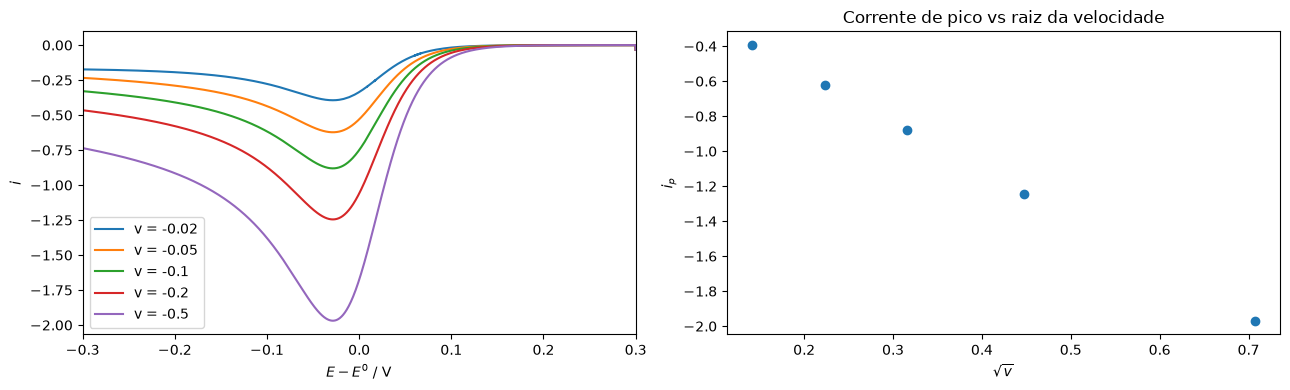

In [7]:
# potenciais fixos para a varredura linear de potencial
DEFAULT_INITIAL_POTENTIAL  =  0.3  # potencial inicial [V]
DEFAULT_FINAL_POTENTIAL    = -0.3  # potencial final [V]
DEFAULT_STANDARD_POTENTIAL =  0    # potencial padrão [V]

scan_rates    = [-0.02, -0.05, -0.1, -0.2, -0.5]  # velocidades de varredura [V/s]
colors        = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

currents      = []
potentials    = []
peak_currents = []

for scan_rate_i in scan_rates:
    final_time = (DEFAULT_FINAL_POTENTIAL - DEFAULT_INITIAL_POTENTIAL) / scan_rate_i
    time       = np.linspace(0, final_time, 1000)

    solution = solver.solve(
        model, time,
        inputs={
            "Potencial Inicial [V]":           DEFAULT_INITIAL_POTENTIAL,
            "Potencial Final [V]":             DEFAULT_FINAL_POTENTIAL,
            "Potencial Padrão [V]":            DEFAULT_STANDARD_POTENTIAL,
            "Velocidade de Varredura [V.s-1]": scan_rate_i,
        }
    )

    flux_o_solution         = solution["Fluxo de O"]
    applied_potential_solution = solution["Potencial Aplicado"]

    current   = flux_o_solution(solution.t, x=0)
    potential = applied_potential_solution(solution.t)

    currents.append(current)
    potentials.append(potential)
    peak_currents.append(np.min(current))  # pico catódico (mínimo, pois a corrente é negativa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for scan_rate_i, color, current, potential in zip(scan_rates, colors, currents, potentials):
    ax1.plot(potential, current, color=color, label=f"v = {scan_rate_i}")

ax1.set_xlabel(r"$E - E^0$ / V")
ax1.set_ylabel(r"$i$")
ax1.set_xlim([DEFAULT_FINAL_POTENTIAL, DEFAULT_INITIAL_POTENTIAL])
ax1.legend(loc="lower left")

scan_rate_roots = [np.sqrt(abs(scan_rate_i)) for scan_rate_i in scan_rates]
ax2.plot(scan_rate_roots, peak_currents, "o", color="tab:blue")
ax2.set_xlabel(r"$\sqrt{v}$")
ax2.set_ylabel(r"$i_p$")
ax2.set_title("Corrente de pico vs raiz da velocidade")

plt.tight_layout()
plt.show()

O gráfico da esquerda mostra os voltamogramas para cinco velocidades de varredura diferentes. Cada curva apresenta um **pico de corrente** ($i_p$) associado ao consumo de $O$ na superfície do eletrodo. À medida que o potencial avança além do pico, a corrente diminui pois a difusão não consegue repor $O$ na superfície na mesma taxa em que este é consumido.

A posição do pico no eixo do potencial corresponde ao **potencial de pico** ($E_p$), que em um sistema reversível se localiza próximo a $E^0$. O **potencial de meio pico** ($E_{p/2}$) é definido como o potencial onde a corrente é metade da corrente de pico. Já o **potencial de meia onda** ($E_{1/2}$), definido como o ponto médio entre $E_p$ e $E_{p/2}$, é uma boa aproximação de $E^0$ para sistemas reversíveis.

O gráfico da direita mostra que a corrente de pico cresce linearmente com a raiz da velocidade de varredura ($\sqrt{v}$), comportamento previsto pela equação de Randles-Ševčík:

$$i_p \propto \sqrt{v}$$

Isso confirma que o processo é controlado por **difusão** — quanto maior a velocidade de varredura, menor o tempo disponível para difusão, resultando em gradientes de concentração mais acentuados e, portanto, correntes de pico maiores.

## Gráfico Interativo: 

In [8]:
output = Output()

def plot(
    initial_potential_1_str, final_potential_1_str,
    standard_potential_1_str, scan_rate_1_str,
    initial_potential_2_str, final_potential_2_str,
    standard_potential_2_str, scan_rate_2_str,
):
    with output:
        clear_output(wait=True)

        # validação das entradas
        try:
            initial_potential_1  = float(initial_potential_1_str)
            final_potential_1    = float(final_potential_1_str)
            standard_potential_1 = float(standard_potential_1_str)
            scan_rate_1          = float(scan_rate_1_str)
            initial_potential_2  = float(initial_potential_2_str)
            final_potential_2    = float(final_potential_2_str)
            standard_potential_2 = float(standard_potential_2_str)
            scan_rate_2          = float(scan_rate_2_str)
        except ValueError:
            print("Por favor, insira valores numéricos válidos.")
            return

        if scan_rate_1 == 0 or scan_rate_2 == 0:
            print("A velocidade de varredura não pode ser zero.")
            return

        # ── curva 1 ───────────────────────────────────────────────────────────
        final_time_1 = (final_potential_1 - initial_potential_1) / scan_rate_1
        solution_1   = solver.solve(
            model, np.linspace(0, final_time_1, 1000),
            inputs={
                "Potencial Inicial [V]":           initial_potential_1,
                "Potencial Final [V]":             final_potential_1,
                "Potencial Padrão [V]":            standard_potential_1,
                "Velocidade de Varredura [V.s-1]": scan_rate_1,
            }
        )
        current_1   = solution_1["Fluxo de O"](solution_1.t, x=0)
        potential_1 = solution_1["Potencial Aplicado"](solution_1.t)

        # ── curva 2 ───────────────────────────────────────────────────────────
        final_time_2 = (final_potential_2 - initial_potential_2) / scan_rate_2
        solution_2   = solver.solve(
            model, np.linspace(0, final_time_2, 1000),
            inputs={
                "Potencial Inicial [V]":           initial_potential_2,
                "Potencial Final [V]":             final_potential_2,
                "Potencial Padrão [V]":            standard_potential_2,
                "Velocidade de Varredura [V.s-1]": scan_rate_2,
            }
        )
        current_2   = solution_2["Fluxo de O"](solution_2.t, x=0)
        potential_2 = solution_2["Potencial Aplicado"](solution_2.t)

        # ── plotagem ──────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(potential_1, current_1, color="tab:blue", linewidth=2, label="1ª Varredura")
        ax.plot(potential_2, current_2, color="tab:red",  linewidth=2, label="2ª Varredura")

        ax.set_xlim([
            min(initial_potential_1, final_potential_1, initial_potential_2, final_potential_2),
            max(initial_potential_1, final_potential_1, initial_potential_2, final_potential_2),
        ])
        ax.set_xlabel(r"$E$ / V")
        ax.set_ylabel(r"$i$")
        ax.set_title("Comparação de Voltamogramas")
        ax.legend()

        plt.tight_layout()
        display(fig)
        plt.close(fig)


# ── Widgets — 1ª Varredura ────────────────────────────────────────────────────

field_initial_potential_1  = Text(value="0.5",  description="$E_{i,1}$ [V]:",  style={"description_width": "initial"})
field_final_potential_1    = Text(value="-0.5", description="$E_{f,1}$ [V]:",    style={"description_width": "initial"})
field_standard_potential_1 = Text(value="0",    description="$E^0_1$ [V]:",   style={"description_width": "initial"})
field_scan_rate_1          = Text(value="-0.1", description="$v_1$ [V/s]:",       style={"description_width": "initial"})


# ── Widgets — 2ª Varredura ────────────────────────────────────────────────────

field_initial_potential_2  = Text(value="0.5",  description="$E_{i,2}$ [V]:",  style={"description_width": "initial"})
field_final_potential_2    = Text(value="-0.5", description="$E_{f,2}$ [V]:",    style={"description_width": "initial"})
field_standard_potential_2 = Text(value="0",    description="$E^0_2$ [V]:",   style={"description_width": "initial"})
field_scan_rate_2          = Text(value="-0.2", description="$v_2$ [V/s]:",       style={"description_width": "initial"})

button = Button(description="Recalcular", button_style="success")

def on_click(b):
    plot(
        field_initial_potential_1.value,  field_final_potential_1.value,
        field_standard_potential_1.value, field_scan_rate_1.value,
        field_initial_potential_2.value,  field_final_potential_2.value,
        field_standard_potential_2.value, field_scan_rate_2.value,
    )

button.on_click(on_click)

interface = VBox([
    HBox([field_initial_potential_1, field_final_potential_1, field_standard_potential_1, field_scan_rate_1]),
    HBox([field_initial_potential_2, field_final_potential_2, field_standard_potential_2, field_scan_rate_2]),
    button,
    output,
])
display(interface)

# exibe o gráfico inicial com os valores padrão
plot(
    field_initial_potential_1.value,  field_final_potential_1.value,
    field_standard_potential_1.value, field_scan_rate_1.value,
    field_initial_potential_2.value,  field_final_potential_2.value,
    field_standard_potential_2.value, field_scan_rate_2.value,
)